In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";

In [2]:
using Revise

In [3]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX;

┌ Info: Precompiling JJDFTX [0d21db8c-e7cb-497b-98f4-4306b49e2569]
└ @ Base loading.jl:1317


Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [5]:
write_map_write_h("wannier", [12, 12, 1], spin=Val('u'))
write_map_write_h("wannier", [12, 12, 1], spin=Val('d'))

In [7]:
HWannierUp, cellmapUp = hwannier("wannierUp.txt", "wannierUp.map.txt"), np.loadtxt("wannierUp.map.txt")
HWannierDn, cellmapDn = hwannier("wannierDn.txt", "wannierDn.map.txt"), np.loadtxt("wannierDn.map.txt");

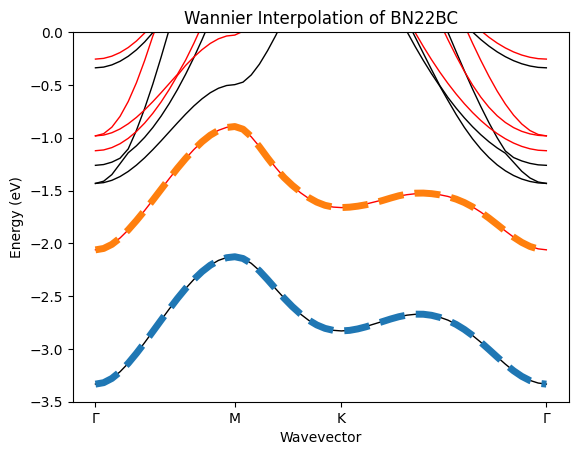

(-3.5, 0.0)

In [21]:
plot_bands("BN22BC.bands.eigenvals", spin=2, to_greek=true, linewidth=1)
title("Wannier Interpolation of BN22BC")
plotwannierbands(HWannierUp, cellmapUp, 1, linewidth=5, linestyle="dashed")

plotwannierbands(HWannierDn, cellmapDn, 1, linewidth=5, linestyle="dashed")
ylim(-3.5, 0)

In [48]:
println(unit_cell_area(loadlattice("BN22BC.out")[2]))
println(1.43*1.43*3*sqrt(3)/2*4)

Lattice loaded from output file in lattice format and in nested array format: 
Note that the lattice format is by convention in Bohrs to be compatible with JDFTX whereas the nested
    array format is in angstroms
21.231100323216236
21.251224178385577


In [37]:
lattice_vectors = loadlattice("BN22BC.out")[2]

Lattice loaded from output file in lattice format and in nested array format: 
Note that the lattice format is by convention in Bohrs to be compatible with JDFTX whereas the nested
    array format is in angstroms


3-element Vector{Vector{Float64}}:
 [4.95131868528, 0.0, 0.0]
 [-2.47565934264, 4.28796885693, 0.0]
 [0.0, 0.0, 21.16708]

In [51]:
kpts = bandstructkpoints2q(interpolate=3);
ωs = 0.01:0.01:3

0.1:0.01:3.0

In [42]:
impols25=[]
impols5=[]
impols75=[]

Any[]

In [135]:
for kpt in kpts
    println("kpt = ", kpt)
    flush(stdout)
    push!(impols10, im_polarization(HWannierUp, cellmapUp, lattice_vectors, kpt, ten_filling, verbose=false, mesh=100))
    #push!(impols5, im_polarization(HWannierUp, cellmapUp, lattice_vectors, kpt, half_filling, verbose=false, mesh=100))
    #push!(impols25, im_polarization(HWannierUp, cellmapUp, lattice_vectors, kpt, quarter_filling, verbose=false, mesh=100))
    #push!(impols75, im_polarization(HWannierUp, cellmapUp, lattice_vectors, kpt, threequarter_filling, verbose=false, mesh=100))
end

kpt = [0.0, 0.0, 0.0]
kpt = [0.009803921568666668, 0.0, 0.0]
kpt = [0.019607843137333335, 0.0, 0.0]
kpt = [0.029411764706, 0.0, 0.0]
kpt = [0.03921568627466667, 0.0, 0.0]
kpt = [0.04901960784333334, 0.0, 0.0]
kpt = [0.058823529412, 0.0, 0.0]
kpt = [0.06862745098066667, 0.0, 0.0]
kpt = [0.07843137254933334, 0.0, 0.0]
kpt = [0.088235294118, 0.0, 0.0]
kpt = [0.09803921568666667, 0.0, 0.0]
kpt = [0.10784313725533334, 0.0, 0.0]
kpt = [0.117647058824, 0.0, 0.0]
kpt = [0.12745098039233332, 0.0, 0.0]
kpt = [0.13725490196066667, 0.0, 0.0]
kpt = [0.147058823529, 0.0, 0.0]
kpt = [0.15686274509766665, 0.0, 0.0]
kpt = [0.16666666666633334, 0.0, 0.0]
kpt = [0.176470588235, 0.0, 0.0]
kpt = [0.18627450980366667, 0.0, 0.0]
kpt = [0.19607843137233333, 0.0, 0.0]
kpt = [0.205882352941, 0.0, 0.0]
kpt = [0.21568627450966665, 0.0, 0.0]
kpt = [0.22549019607833334, 0.0, 0.0]
kpt = [0.235294117647, 0.0, 0.0]
kpt = [0.24509803921566667, 0.0, 0.0]
kpt = [0.25490196078433336, 0.0, 0.0]
kpt = [0.264705882353, 0.0, 

In [136]:
#epsilons25=zeros(length(kpts), length(ωs))
#epsilons5=zeros(length(kpts), length(ωs))
#epsilons75=zeros(length(kpts), length(ωs))
epsilons10=zeros(length(kpts), length(ωs))
for (i, kpt) in enumerate(kpts)
    for (j, ω) in enumerate(ωs)
        epsilons10[i, j] = real(return_2d_epsilon(kpt, lattice_vectors, ω, impols10[i], 100, 100))
        #epsilons25[i, j] = real(return_2d_epsilon(kpt, lattice_vectors, ω, impols25[i], 100, 100))
        #epsilons5[i, j] = real(return_2d_epsilon(kpt, lattice_vectors, ω, impols5[i+167], 100, 100))
        #epsilons75[i, j] = real(return_2d_epsilon(kpt, lattice_vectors, ω, impols75[i], 100, 100))
    end
end

In [121]:
function return_right_plasmon(row)
    isempty(argminima(log.(abs.(row)))) && return ωs[argmin(log.(abs.(row)))] 
    return argminima(log.(abs.(row)))[end]
end

return_right_plasmon (generic function with 2 methods)

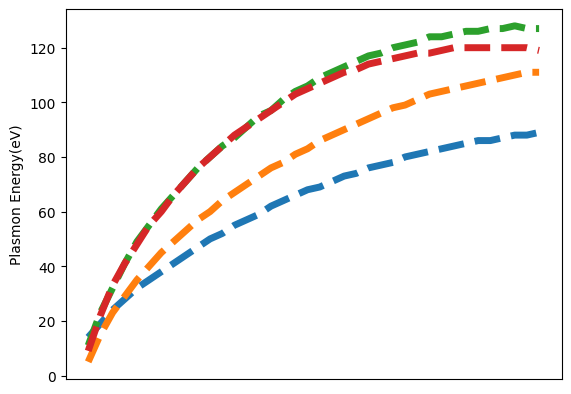

PyObject Text(24.000000000000007, 0.5, 'Plasmon Energy(eV)')

In [146]:
plot([return_right_plasmon(row) for row in eachrow(epsilons10)][3:40], linewidth=5, linestyle="dashed", label="filling :0.1")
plot([return_right_plasmon(row) for row in eachrow(epsilons25)][3:40], linewidth=5, linestyle="dashed", label="filling: 0.25")
plot([return_right_plasmon(row) for row in eachrow(epsilons5)][3:40], linewidth=5, linestyle="dashed", label="filling: 0.5")
plot([return_right_plasmon(row) for row in eachrow(epsilons75)][3:40], linewidth=5, linestyle="dashed", label="filling: 0.75")

xticks([])
ylabel("Plasmon Energy(eV)")

In [17]:
x, y  = find_chemical_potential(HWannierUp, cellmapUp, 1, offset=4, mesh=200, histogram_width=2000)

(Any[-3.9995, -3.999, -3.9985, -3.998, -3.9975, -3.997, -3.9965, -3.996, -3.9955, -3.995  …  5.9955, 5.996, 5.996499999999999, 5.997, 5.9975000000000005, 5.997999999999999, 5.9985, 5.9990000000000006, 5.999499999999999, 6.0], Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0])

In [131]:
ten_filling = x[argmin(abs.(y.- 0.1))]
quarter_filling = x[argmin(abs.(y.- 0.25))]
half_filling = x[argmin(abs.(y.- 0.5))]
threequarter_filling = x[argmin(abs.(y.- 0.75))]

-2.464

In [132]:
ten_filling

-2.9844999999999997

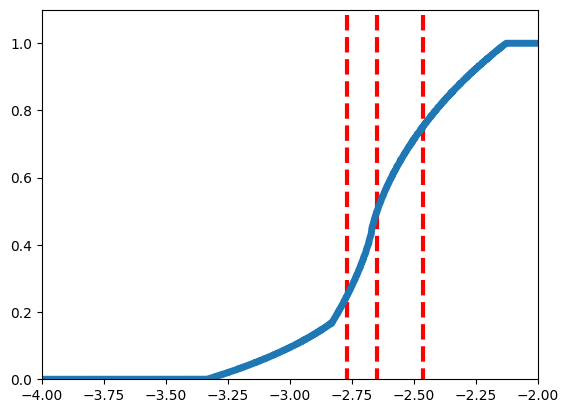

(0.0, 1.1)

In [34]:
plot(x, y, linewidth=5)
vlines([quarter_filling, half_filling, threequarter_filling], -1, 2, linewidth=3, linestyle="dashed", color="red")
xlim(-4, -2)
ylim(0, 1.1)

In [83]:
0.7*1.5

1.0499999999999998

In [90]:
?union

search: union Union union! Union{} UnionAll function Function functionloc



```
union(s, itrs...)
∪(s, itrs...)
```

Construct the union of sets. Maintain order with arrays.

# Examples

```jldoctest
julia> union([1, 2], [3, 4])
4-element Vector{Int64}:
 1
 2
 3
 4

julia> union([1, 2], [2, 4])
3-element Vector{Int64}:
 1
 2
 4

julia> union([4, 2], 1:2)
3-element Vector{Int64}:
 4
 2
 1

julia> union(Set([1, 2]), 2:3)
Set{Int64} with 3 elements:
  2
  3
  1
```

---

```
union(intervals::AbstractVector{<:AbstractInterval})
```

Flattens a vector of overlapping intervals into a new, smaller vector containing only non-overlapping intervals.

---

```
union(ss, iterable...)
```

This function creates a new SortedSet (the return argument) and inserts each item from `ss` and each item from each iterable argument into the returned SortedSet. Time: O(*cn* log *n*) where *n* is the total number of items in all the arguments.
